# Final_Project_taap_p4

### Developed by:

- António Cruz (140129)
- Cátia Brás (120093)
- Ricardo Kyaseller (95813)

## 1. Introduction and Project Goals

gdgdgdgdgd

## 2. Environment, Reproducibility and Experimental Setup

### 2.1 Libraries Import

In [19]:
import os
import gc
import sys
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
import psutil

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

### GPU Test

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1774275249.736874   27805 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


### 2.2 Utils Configuration Test

In [22]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/home/ricarl/taap_p4


In [23]:
from src.utils.env import set_global_seed, enable_gpu_memory_growth, get_device_info

SEED = 42
set_global_seed(SEED)
enable_gpu_memory_growth()

print(get_device_info())

{'tensorflow_version': '2.21.0', 'num_gpus': 1, 'gpus': ['/physical_device:GPU:0'], 'num_cpus': 1, 'cpus': ['/physical_device:CPU:0']}


## 3. Dataset and Problem Definition

### 3.1 Load Data

In [25]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "src" / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists?", DATA_DIR.exists())

PROJECT_ROOT: /home/ricarl/taap_p4
DATA_DIR: /home/ricarl/taap_p4/src/data
DATA_DIR exists? True


In [26]:
DATASET_PATH = DATA_DIR / "jena_climate_2009_2016.csv"

df = pd.read_csv(DATASET_PATH)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### 3.2 Initial Dataset Inspection

In [24]:
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Dataset path: /home/ricarl/taap_p4/src/data/jena_climate_2009_2016.csv
Shape: (420551, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/

### 3.2 Data Quality Checks

In [27]:
print("Duplicated rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())

Duplicated rows: 327

Missing values per column:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [28]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicated rows after cleanup:", df.duplicated().sum())

Shape after removing duplicates: (420224, 15)
Duplicated rows after cleanup: 0


### 3.3 Datetime Parsing and Temporal Ordering

In [30]:
df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)
df = df.sort_values("Date Time").reset_index(drop=True)

print(df["Date Time"].min(), "->", df["Date Time"].max())
df[["Date Time"]].head()

2009-01-01 00:10:00 -> 2017-01-01 00:00:00


,Date Time
0,2009-01-01 00:10:00
1,2009-01-01 00:20:00
2,2009-01-01 00:30:00
3,2009-01-01 00:40:00
4,2009-01-01 00:50:00


In [31]:
df["Date Time"].diff().value_counts().head(10)

Date Time
0 days 00:10:00    420218
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

### 3.4 Hourly Resampling

In [32]:
df_hourly = (
    df.set_index("Date Time")
      .resample("1h")
      .mean()
      .reset_index()
)

print("Original shape:", df.shape)
print("Hourly shape:", df_hourly.shape)
print(df_hourly.head())

Original shape: (420224, 15)
Hourly shape: (70129, 15)
            Date Time    p (mbar)  T (degC)    Tpot (K)  Tdew (degC)  \
0 2009-01-01 00:00:00  996.528000 -8.304000  265.118000    -9.120000   
1 2009-01-01 01:00:00  996.525000 -8.065000  265.361667    -8.861667   
2 2009-01-01 02:00:00  996.745000 -8.763333  264.645000    -9.610000   
3 2009-01-01 03:00:00  996.986667 -8.896667  264.491667    -9.786667   
4 2009-01-01 04:00:00  997.158333 -9.348333  264.026667   -10.345000   

      rh (%)  VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
0  93.780000      3.260000      3.058000      0.202000   1.910000   
1  93.933333      3.323333      3.121667      0.201667   1.951667   
2  93.533333      3.145000      2.940000      0.201667   1.836667   
3  93.200000      3.111667      2.898333      0.210000   1.811667   
4  92.383333      3.001667      2.775000      0.231667   1.733333   

   H2OC (mmol/mol)  rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd (deg)  
0         3.068000   1309

### 3.5 Post-Resampling Quality Check

In [33]:
print("Missing values after hourly resampling:")
print(df_hourly.isna().sum())

print("\nDuplicated timestamps after resampling:", df_hourly["Date Time"].duplicated().sum())

print("\nTime step distribution after resampling:")
print(df_hourly["Date Time"].diff().value_counts().head(10))

Missing values after hourly resampling:
Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           88
max. wv (m/s)      88
wd (deg)           88
dtype: int64

Duplicated timestamps after resampling: 0

Time step distribution after resampling:
Date Time
0 days 01:00:00    70128
Name: count, dtype: int64


### 3.6 Handling Missing Values After Resampling

In [34]:
df_hourly = df_hourly.dropna().reset_index(drop=True)

print("Shape after dropping NaNs:", df_hourly.shape)
print("\nMissing values after cleanup:")
print(df_hourly.isna().sum().sum())
print("\nTime step distribution after cleanup:")
print(df_hourly["Date Time"].diff().value_counts().head())

Shape after dropping NaNs: (70041, 15)

Missing values after cleanup:
0

Time step distribution after cleanup:
Date Time
0 days 01:00:00    70038
0 days 16:00:00        1
3 days 02:00:00        1
Name: count, dtype: int64


### 3.7 Forecasting Task and Variable Selection

In [35]:
selected_columns = [
    "Date Time",
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

df_model = df_hourly[selected_columns].copy()

print("Selected columns:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Selected columns:
['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Shape: (70041, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


## 4. Data Initial Preparation

### 4.1 Target Definition and Base Modeling DataFrame

In [36]:
TARGET_COL = "T (degC)"
TIME_COL = "Date Time"

feature_cols = [col for col in df_model.columns if col not in [TIME_COL]]
input_feature_cols = [col for col in feature_cols]

print("Target:", TARGET_COL)
print("Time column:", TIME_COL)
print("Input features:", input_feature_cols)
print("Number of input features:", len(input_feature_cols))

Target: T (degC)
Time column: Date Time
Input features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Number of input features: 6


### 4.2 Base Forecasting Data Overview

In [37]:
print(df_model.head())
print("\nShape:", df_model.shape)
print("\nDate range:", df_model[TIME_COL].min(), "->", df_model[TIME_COL].max())

            Date Time  T (degC)    p (mbar)     rh (%)  wv (m/s)  \
0 2009-01-01 00:00:00 -8.304000  996.528000  93.780000  0.520000   
1 2009-01-01 01:00:00 -8.065000  996.525000  93.933333  0.316667   
2 2009-01-01 02:00:00 -8.763333  996.745000  93.533333  0.248333   
3 2009-01-01 03:00:00 -8.896667  996.986667  93.200000  0.176667   
4 2009-01-01 04:00:00 -9.348333  997.158333  92.383333  0.290000   

   max. wv (m/s)    wd (deg)  
0       1.002000  174.460000  
1       0.711667  172.416667  
2       0.606667  196.816667  
3       0.606667  157.083333  
4       0.670000  150.093333  

Shape: (70041, 7)

Date range: 2009-01-01 00:00:00 -> 2017-01-01 00:00:00


## 5. Feature Engineering

### 5.1 Cyclical Time Features

In [38]:
df_feat = df_model.copy()

df_feat["hour"] = df_feat[TIME_COL].dt.hour
df_feat["dayofyear"] = df_feat[TIME_COL].dt.dayofyear

df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)

df_feat["doy_sin"] = np.sin(2 * np.pi * df_feat["dayofyear"] / 365.25)
df_feat["doy_cos"] = np.cos(2 * np.pi * df_feat["dayofyear"] / 365.25)

df_feat[[
    TIME_COL, "hour", "dayofyear",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]].head()

,Date Time,hour,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos
0,2009-01-01 00:00:00,0,1,0.000000,1.000000,0.017202,0.999852
1,2009-01-01 01:00:00,1,1,0.258819,0.965926,0.017202,0.999852
2,2009-01-01 02:00:00,2,1,0.500000,0.866025,0.017202,0.999852
3,2009-01-01 03:00:00,3,1,0.707107,0.707107,0.017202,0.999852
4,2009-01-01 04:00:00,4,1,0.866025,0.500000,0.017202,0.999852


### 5.2 Wind-Derived Features

In [39]:
wd_rad = np.deg2rad(df_feat["wd (deg)"])

df_feat["wd_sin"] = np.sin(wd_rad)
df_feat["wd_cos"] = np.cos(wd_rad)

df_feat["wx"] = df_feat["wv (m/s)"] * np.cos(wd_rad)
df_feat["wy"] = df_feat["wv (m/s)"] * np.sin(wd_rad)

df_feat["wind_gap"] = df_feat["max. wv (m/s)"] - df_feat["wv (m/s)"]
df_feat["gust_ratio"] = df_feat["max. wv (m/s)"] / (df_feat["wv (m/s)"] + 1e-6)

df_feat[[
    TIME_COL, "wv (m/s)", "max. wv (m/s)", "wd (deg)",
    "wd_sin", "wd_cos", "wx", "wy", "wind_gap", "gust_ratio"
]].head()

,Date Time,wv (m/s),max. wv (m/s),wd (deg),wd_sin,wd_cos,wx,wy,wind_gap,gust_ratio
0,2009-01-01 00:00:00,0.520000,1.002000,174.460000,0.096541,-0.995329,-0.517571,0.050201,0.482000,1.926919
1,2009-01-01 01:00:00,0.316667,0.711667,172.416667,0.131968,-0.991254,-0.313897,0.041790,0.395000,2.247361
2,2009-01-01 02:00:00,0.248333,0.606667,196.816667,-0.289310,-0.957235,-0.237713,-0.071845,0.358333,2.442943
3,2009-01-01 03:00:00,0.176667,0.606667,157.083333,0.389392,-0.921072,-0.162723,0.068793,0.430000,3.433943
4,2009-01-01 04:00:00,0.290000,0.670000,150.093333,0.498589,-0.866839,-0.251383,0.144591,0.380000,2.310337


### 5.3 Final Feature Set for Modeling

In [40]:
final_feature_cols = [
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "wd_sin",
    "wd_cos",
    "wx",
    "wy",
    "wind_gap",
    "gust_ratio",
]

print("Number of modeling features:", len(final_feature_cols))
print(final_feature_cols)

Number of modeling features: 16
['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos', 'wx', 'wy', 'wind_gap', 'gust_ratio']


## 6. Split, Scaling and Windowing

### 6.1 Temporal Train/Validation/Test Split

In [41]:
n = len(df_feat)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_feat.iloc[:train_end].copy()
df_val = df_feat.iloc[train_end:val_end].copy()
df_test = df_feat.iloc[val_end:].copy()

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

print("\nTrain range:", df_train[TIME_COL].min(), "->", df_train[TIME_COL].max())
print("Validation range:", df_val[TIME_COL].min(), "->", df_val[TIME_COL].max())
print("Test range:", df_test[TIME_COL].min(), "->", df_test[TIME_COL].max())

Train shape: (49028, 19)
Validation shape: (10506, 19)
Test shape: (10507, 19)

Train range: 2009-01-01 00:00:00 -> 2014-08-05 19:00:00
Validation range: 2014-08-05 20:00:00 -> 2015-10-18 04:00:00
Test range: 2015-10-18 05:00:00 -> 2017-01-01 00:00:00


### 6.2 Feature Scaling

In [42]:
scaler = StandardScaler()

X_train_df = df_train[final_feature_cols].copy()
X_val_df = df_val[final_feature_cols].copy()
X_test_df = df_test[final_feature_cols].copy()

X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)
X_test_scaled = scaler.transform(X_test_df)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (49028, 16)
Scaled val shape: (10506, 16)
Scaled test shape: (10507, 16)


### 6.3 Target Index for Forecasting

In [43]:
target_idx = final_feature_cols.index(TARGET_COL)

print("Target column:", TARGET_COL)
print("Target index:", target_idx)

Target column: T (degC)
Target index: 0


### 6.4 Supervised Windowing

In [44]:
LOOKBACK = 120
HORIZON = 24

def make_windows(data, target_idx, lookback=120, horizon=24):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback:i + lookback + horizon, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(X_train_scaled, target_idx, LOOKBACK, HORIZON)
X_val, y_val = make_windows(X_val_scaled, target_idx, LOOKBACK, HORIZON)
X_test, y_test = make_windows(X_test_scaled, target_idx, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (48885, 120, 16) y_train: (48885, 24)
X_val: (10363, 120, 16) y_val: (10363, 24)
X_test: (10364, 120, 16) y_test: (10364, 24)


### 6.5 Windowed Data Sanity Check

In [45]:
print("Input shape:", X_train.shape[1:])
print("Forecast horizon:", y_train.shape[1])
print("Number of input features:", X_train.shape[2])

print("\nExample input window shape:", X_train[0].shape)
print("Example target shape:", y_train[0].shape)
print("First 5 target values (scaled):", y_train[0][:5])

Input shape: (120, 16)
Forecast horizon: 24
Number of input features: 16

Example input window shape: (120, 16)
Example target shape: (24,)
First 5 target values (scaled): [-2.55218147 -2.61156348 -2.64453206 -2.68540539 -2.73726824]


## 7. Baseline Models

### 7.1 Persistence Baseline

In [46]:
def persistence_forecast(X):
    # Repeats the last observed target value across the full forecast horizon
    last_temp = X[:, -1, target_idx]
    return np.repeat(last_temp[:, None], HORIZON, axis=1)

y_pred_persistence = persistence_forecast(X_test)

print("Persistence prediction shape:", y_pred_persistence.shape)
print("First prediction:", y_pred_persistence[0][:5])

Persistence prediction shape: (10364, 24)
First prediction: [-0.04174932 -0.04174932 -0.04174932 -0.04174932 -0.04174932]


In [47]:
persistence_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_persistence.flatten())
persistence_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_persistence.flatten()))

print("Persistence MAE (scaled):", persistence_mae_scaled)
print("Persistence RMSE (scaled):", persistence_rmse_scaled)

Persistence MAE (scaled): 0.3636531434000367
Persistence RMSE (scaled): 0.4921206134926399


In [48]:
def build_gru_baseline(input_shape, horizon):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(horizon)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

gru_baseline = build_gru_baseline(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    horizon=HORIZON
)

gru_baseline.summary()

W0000 00:00:1774280552.518102   27805 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774280552.737501   27805 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,464 (83.84 KB)

 Trainable params: 21,464 (83.84 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


I0000 00:00:1774280604.482458   43713 cuda_dnn.cc:461] Loaded cuDNN version 92000


764/764 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1371 - mae: 0.2715 - val_loss: 0.0786 - val_mae: 0.2120
Epoch 2/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0831 - mae: 0.2212 - val_loss: 0.0738 - val_mae: 0.2044
Epoch 3/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0771 - mae: 0.2125 - val_loss: 0.0725 - val_mae: 0.2019
Epoch 4/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0731 - mae: 0.2064 - val_loss: 0.0714 - val_mae: 0.1996
Epoch 5/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0700 - mae: 0.2017 - val_loss: 0.0718 - val_mae: 0.1995
Epoch 6/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0673 - mae: 0.1979 - val_loss: 0.0723 - val_mae: 0.1997
Epoch 7/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0647 - mae: 0.1944 - val_loss: 0.0749 - val_mae: 0.2036
Epoch 8/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0619 - mae: 0.1904 - val_loss: 0.0753 - val_mae: 0.2023
Epoch 9/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - los

In [50]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:5])

Prediction shape: (10364, 24)
First prediction: [-0.1388869  -0.1972229  -0.15495412 -0.10705377 -0.00417533]


In [51]:
gru_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_gru.flatten())
gru_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_gru.flatten()))

print("GRU MAE (scaled):", gru_mae_scaled)
print("GRU RMSE (scaled):", gru_rmse_scaled)

GRU MAE (scaled): 0.19175428576586087
GRU RMSE (scaled): 0.2538402367201472


### 7.2 GRU Baseline

In [53]:
OFFICIAL_GRU_CFG = {
    "n_layers": 2,
    "units1": 96,
    "units2": 64,
    "units3": 96,
    "dropout": 0.0,
    "l2": 1e-6,
    "dense_units": 256,
    "dense_activation": "relu",
    "lr": 2e-4,
    "batch_size": 128,
    "clipnorm": 2.0,
    "optimizer": "adamw",
    "weight_decay": 1e-6,
    "loss_name": "huber1",
    "gaussian_noise_std": 0.0,
}

def build_official_gru_baseline(input_shape, horizon, cfg):
    reg = keras.regularizers.l2(cfg["l2"]) if cfg["l2"] > 0 else None
    
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))
    
    if cfg["gaussian_noise_std"] > 0:
        model.add(layers.GaussianNoise(cfg["gaussian_noise_std"]))
    
    if cfg["n_layers"] == 1:
        model.add(
            layers.GRU(
                cfg["units1"],
                return_sequences=False,
                kernel_regularizer=reg,
                recurrent_regularizer=reg,
            )
        )
    elif cfg["n_layers"] == 2:
        model.add(
            layers.GRU(
                cfg["units1"],
                return_sequences=True,
                kernel_regularizer=reg,
                recurrent_regularizer=reg,
            )
        )
        if cfg["dropout"] > 0:
            model.add(layers.Dropout(cfg["dropout"]))
        model.add(
            layers.GRU(
                cfg["units2"],
                return_sequences=False,
                kernel_regularizer=reg,
                recurrent_regularizer=reg,
            )
        )
    else:
        model.add(
            layers.GRU(
                cfg["units1"],
                return_sequences=True,
                kernel_regularizer=reg,
                recurrent_regularizer=reg,
            )
        )
        if cfg["dropout"] > 0:
            model.add(layers.Dropout(cfg["dropout"]))
        model.add(
            layers.GRU(
                cfg["units2"],
                return_sequences=True,
                kernel_regularizer=reg,
                recurrent_regularizer=reg,
            )
        )
        if cfg["dropout"] > 0:
            model.add(layers.Dropout(cfg["dropout"]))
        model.add(
            layers.GRU(
                cfg["units3"],
                return_sequences=False,
                kernel_regularizer=reg,
                recurrent_regularizer=reg,
            )
        )

    if cfg["dropout"] > 0:
        model.add(layers.Dropout(cfg["dropout"]))

    if cfg["dense_units"] > 0:
        model.add(layers.Dense(cfg["dense_units"], activation=cfg["dense_activation"]))

    model.add(layers.Dense(horizon))

    if cfg["optimizer"] == "adamw":
        optimizer = keras.optimizers.AdamW(
            learning_rate=cfg["lr"],
            weight_decay=cfg["weight_decay"],
            clipnorm=cfg["clipnorm"],
        )
    else:
        optimizer = keras.optimizers.Adam(
            learning_rate=cfg["lr"],
            clipnorm=cfg["clipnorm"],
        )

    if cfg["loss_name"] == "huber1":
        loss = keras.losses.Huber(delta=1.0)
    elif cfg["loss_name"] == "mae":
        loss = "mae"
    else:
        loss = "mse"

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["mae"],
    )
    return model

gru_baseline = build_official_gru_baseline(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    horizon=HORIZON,
    cfg=OFFICIAL_GRU_CFG,
)

gru_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 120, 96)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,744 (338.84 KB)

 Trainable params: 86,744 (338.84 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=OFFICIAL_GRU_CFG["batch_size"],
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0914 - mae: 0.3121 - val_loss: 0.0443 - val_mae: 0.2286
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0398 - mae: 0.2159 - val_loss: 0.0404 - val_mae: 0.2159
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0372 - mae: 0.2073 - val_loss: 0.0389 - val_mae: 0.2110
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0357 - mae: 0.2023 - val_loss: 0.0381 - val_mae: 0.2080
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0346 - mae: 0.1986 - val_loss: 0.0374 - val_mae: 0.2056
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0337 - mae: 0.1954 - val_loss: 0.0368 - val_mae: 0.2038
Epoch 7/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0329 - mae: 0.1926 - val_loss: 0.0364 - val_mae: 0.2022
Epoch 8/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0321 - mae: 0.1900 - val_loss: 0.0360 - val_mae: 0.2009
Epoch 9/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/

In [55]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:5])

Prediction shape: (10364, 24)
First prediction: [-0.12111076 -0.14372127 -0.10919145 -0.08321766 -0.02476098]


In [56]:
gru_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_gru.flatten())
gru_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_gru.flatten()))

print("GRU Baseline MAE (scaled):", gru_mae_scaled)
print("GRU Baseline RMSE (scaled):", gru_rmse_scaled)

GRU Baseline MAE (scaled): 0.19252097657578432
GRU Baseline RMSE (scaled): 0.25556863938850655


### 7.3 Baseline Comparison

In [57]:
baseline_results_scaled = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
})

baseline_results_scaled

,Model,MAE_scaled,RMSE_scaled
0,Persistence,0.363653,0.492121
1,GRU Baseline Official,0.192521,0.255569


### 7.4 Reverse Scaling

In [58]:
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]

def inverse_scale_target(y_scaled, mean, std):
    return y_scaled * std + mean

y_test_inv = inverse_scale_target(y_test, target_mean, target_std)
y_pred_persistence_inv = inverse_scale_target(y_pred_persistence, target_mean, target_std)
y_pred_gru_inv = inverse_scale_target(y_pred_gru, target_mean, target_std)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_gru_inv shape:", y_pred_gru_inv.shape)

y_test_inv shape: (10364, 24)
y_pred_gru_inv shape: (10364, 24)


### 7.5 Baseline Evaluation in Original Temperature Scale

In [59]:
persistence_mae = mean_absolute_error(y_test_inv.flatten(), y_pred_persistence_inv.flatten())
persistence_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), y_pred_persistence_inv.flatten()))

gru_mae = mean_absolute_error(y_test_inv.flatten(), y_pred_gru_inv.flatten())
gru_rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), y_pred_gru_inv.flatten()))

print("Persistence MAE (°C):", persistence_mae)
print("Persistence RMSE (°C):", persistence_rmse)
print("GRU Baseline MAE (°C):", gru_mae)
print("GRU Baseline RMSE (°C):", gru_rmse)

Persistence MAE (°C): 3.143633779053561
Persistence RMSE (°C): 4.254182899340968
GRU Baseline MAE (°C): 1.6642656776769498
GRU Baseline RMSE (°C): 2.209287124914721


### 7.6 Final Baseline Comparison

In [60]:
baseline_results = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
    "MAE_degC": [persistence_mae, gru_mae],
    "RMSE_degC": [persistence_rmse, gru_rmse],
})

baseline_results

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,Persistence,0.363653,0.492121,3.143634,4.254183
1,GRU Baseline Official,0.192521,0.255569,1.664266,2.209287


### 7.6 Example Forecast Visualization

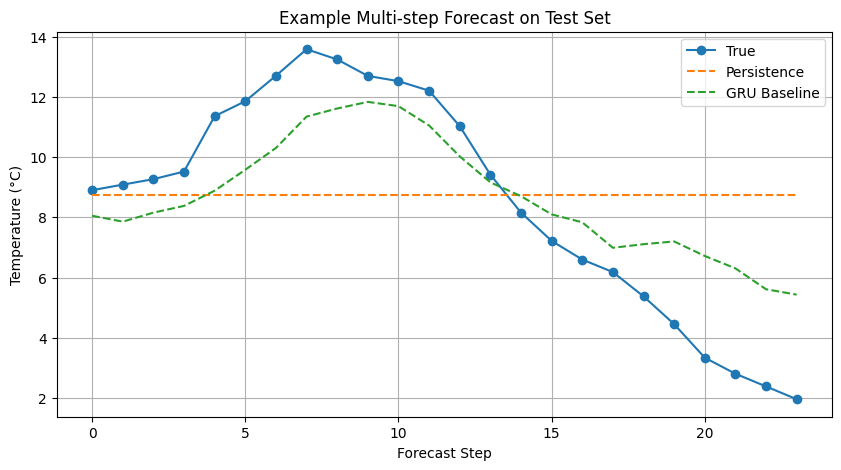

In [62]:
sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[sample_idx], label="True", marker="o")
plt.plot(y_pred_persistence_inv[sample_idx], label="Persistence", linestyle="--")
plt.plot(y_pred_gru_inv[sample_idx], label="GRU Baseline", linestyle="--")
plt.title("Example Multi-step Forecast on Test Set")
plt.xlabel("Forecast Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Synthetic Data Generation with TimeGAN

## 9. Evolutionary Optimization of the Forecasting Pipeline

## 10. Retraining and Final Model Selection

## 11. Explainable AI

### 11.1 Global Explainability

### 11.2 Local Explainability

## 12. Efficiency, Latency and Resource Analysis

## 13. Comparative Discussion

## 14. Conclusion